In [17]:
!pip -q install lightgbm pyarrow

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    roc_auc_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 1. Paths and configuration


In [19]:
PROJECT_NAME = "alpha_ml"
BASE_DIR = Path("/content/drive/MyDrive") / PROJECT_NAME

FEATURES_DIR = BASE_DIR / "data" / "features"
MODELS_DIR = BASE_DIR / "models" / "02_cross_sectional"
RESULTS_DIR = BASE_DIR / "results"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
CHECKPOINT_ROOT = RESULTS_DIR / "02_checkpoints"
DATA_PATH = FEATURES_DIR / "model_dataset_full.parquet"
CONFIG_PATH = BASE_DIR / "config.json"

for directory in [MODELS_DIR, RESULTS_DIR, PREDICTIONS_DIR, CHECKPOINT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

TRAIN_END = pd.Timestamp("2021-12-31")
VALID_END = pd.Timestamp("2023-12-31")
LOOKBACK = 60
NN_DATES_PER_BATCH = 1
MAX_EPOCHS = 50
PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 64
DROPOUT = 0.20
CROSS_SECTION_LAYERS = 1
DIRECTIONAL_LOSS_WEIGHT = 1.0
LGBM_N_ESTIMATORS = 1000
LGBM_EARLY_STOPPING = 50
RESUME_COMPLETED_WINDOWS = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FAST_DEV_RUN = False
if FAST_DEV_RUN:
    RUN_WINDOWS = [int(config["return_windows"][0])]
    MODEL_NAMES_TO_RUN = ["FCNN"]
    MAX_EPOCHS = 2
    PATIENCE = 2
    LGBM_N_ESTIMATORS = 30
    LGBM_EARLY_STOPPING = 5
    MAX_TRAIN_DATES = 20
    MAX_VALID_DATES = 10
    MAX_TRAIN_VALID_DATES = 30
    MAX_TEST_DATES = 10
    OUTPUT_SUFFIX = "_directional_dev"
else:
    RUN_WINDOWS = [int(w) for w in config["return_windows"]]
    MODEL_NAMES_TO_RUN = None
    MAX_TRAIN_DATES = None
    MAX_VALID_DATES = None
    MAX_TRAIN_VALID_DATES = None
    MAX_TEST_DATES = None
    OUTPUT_SUFFIX = "_directional"


def seed_everything(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()
print("Device:", DEVICE)
print("Windows:", RUN_WINDOWS)
print("FAST_DEV_RUN:", FAST_DEV_RUN)

Device: cuda
Windows: [1, 3, 5, 10, 20, 60]
FAST_DEV_RUN: False


## 2. Load notebook 01 output and create horizon-specific targets


In [20]:
df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

if df.duplicated(["date", "ticker"]).any():
    raise ValueError("Duplicate date-ticker rows found. Fix notebook 01 first.")

df["ticker_row_number"] = df.groupby("ticker").cumcount()

for window in RUN_WINDOWS:
    df[f"future_ret_{window}d"] = (
        df.groupby("ticker")[f"ret_{window}d"].shift(-window)
    )
    df[f"target_end_date_{window}d"] = (
        df.groupby("ticker")["date"].shift(-window)
    )

universe_df = df.loc[df["in_universe"]].copy()

for window in RUN_WINDOWS:
    future_col = f"future_ret_{window}d"
    end_column = f"target_end_date_{window}d"  # must be redefined for every window
    future_rank = universe_df.groupby("date")[future_col].rank(
        pct=True,
        method="average",
    )
    universe_df[f"future_rank_{window}d"] = future_rank

    universe_df[f"bottom20_{window}d"] = (
        future_rank.lt(0.20).astype("Int8").where(future_rank.notna())
    )
    universe_df[f"middle60_{window}d"] = (
        future_rank.between(0.20, 0.80, inclusive="both")
        .astype("Int8")
        .where(future_rank.notna())
    )
    universe_df[f"top20_{window}d"] = (
        future_rank.gt(0.80).astype("Int8").where(future_rank.notna())
    )

    target = pd.Series(pd.NA, index=universe_df.index, dtype="Int8")
    target.loc[universe_df[f"bottom20_{window}d"].eq(1)] = 0
    target.loc[universe_df[f"middle60_{window}d"].eq(1)] = 1
    target.loc[universe_df[f"top20_{window}d"].eq(1)] = 2
    universe_df[f"target_class_{window}d"] = target

    universe_df[f"keep_train_{window}d"] = (
        universe_df["date"].le(TRAIN_END)
        & universe_df[end_column].le(TRAIN_END)
    )
    universe_df[f"keep_validation_{window}d"] = (
        universe_df["date"].gt(TRAIN_END)
        & universe_df["date"].le(VALID_END)
        & universe_df[end_column].le(VALID_END)
    )
    universe_df[f"keep_train_validation_{window}d"] = (
        universe_df["date"].le(VALID_END)
        & universe_df[end_column].le(VALID_END)
    )
    universe_df[f"keep_test_prediction_{window}d"] = (
        universe_df["date"].gt(VALID_END)
    )

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Rows:", f"{len(df):,}", "Universe rows:", f"{int(df['in_universe'].sum()):,}")

Date range: 2015-01-02 to 2025-12-30
Rows: 3,828,683 Universe rows: 1,257,000


## 3. Features and training-only robust scaling

Rank features remain in `[0, 1]`. Only `ret_*d`, `vol_*d`, and `close_to_ma_*d` are transformed:

$$x_{scaled}=\operatorname{clip}\left(\frac{x-\mathrm{training\ median}}{Q_{0.75}-Q_{0.25}},-5,5\right).$$


In [21]:
rank_feature_cols = (
    ["adj_close_rank", "volume_rank", "dollar_volume_rank", "dollar_volume_20d_rank"]
    + [f"ret_{w}d_rank" for w in config["return_windows"]]
    + [f"vol_{w}d_rank" for w in config["volatility_windows"]]
    + ["volume_20d_mean_rank", "volume_relative_20d_rank"]
)

continuous_feature_cols = (
    [f"ret_{w}d" for w in config["return_windows"]]
    + [f"vol_{w}d" for w in config["volatility_windows"]]
    + [f"close_to_ma_{w}d" for w in config["moving_average_windows"]]
)
feature_cols = rank_feature_cols + continuous_feature_cols

missing_features = sorted(set(feature_cols) - set(df.columns))
if missing_features:
    raise ValueError(f"Missing features: {missing_features}")

scale_fit_mask = df["date"].le(TRAIN_END) & df["in_universe"]
scale_fit = df.loc[scale_fit_mask, continuous_feature_cols].replace(
    [np.inf, -np.inf], np.nan
)
continuous_center = scale_fit.median()
continuous_scale = scale_fit.quantile(0.75) - scale_fit.quantile(0.25)
continuous_scale = continuous_scale.mask(continuous_scale.abs().lt(1e-8), 1.0)

df[continuous_feature_cols] = (
    df[continuous_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .sub(continuous_center)
    .div(continuous_scale)
    .clip(-5.0, 5.0)
)

# universe_df was copied before scaling, so update its model inputs from df.
universe_df.loc[:, continuous_feature_cols] = df.loc[
    universe_df.index, continuous_feature_cols
]

feature_fill_values = (
    df.loc[scale_fit_mask, feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .median()
)

# LightGBM uses only date t-1 inputs.
lagged_feature_cols = []
for col in feature_cols:
    lagged_col = f"{col}_lag1"
    universe_df[lagged_col] = (
        df.groupby("ticker", sort=False)[col].shift(1).loc[universe_df.index]
    )
    lagged_feature_cols.append(lagged_col)

print("Rank features:", len(rank_feature_cols))
print("Robust-scaled continuous features:", len(continuous_feature_cols))

Rank features: 14
Robust-scaled continuous features: 10


## 4. Split helpers and purge diagnostics


In [22]:
def limit_dates(rows, maximum_dates):
    rows = rows.sort_values(["date", "ticker"]).copy()
    if maximum_dates is not None:
        selected_dates = rows["date"].drop_duplicates().iloc[:maximum_dates]
        rows = rows.loc[rows["date"].isin(selected_dates)].copy()
    return rows


def get_model_rows(window, split):
    target_col = f"target_class_{window}d"
    keep = (
        universe_df[f"keep_{split}_{window}d"]
        & universe_df["ticker_row_number"].ge(LOOKBACK)
    )
    if split != "test_prediction":
        keep &= universe_df[target_col].notna()

    limits = {
        "train": MAX_TRAIN_DATES,
        "validation": MAX_VALID_DATES,
        "train_validation": MAX_TRAIN_VALID_DATES,
        "test_prediction": MAX_TEST_DATES,
    }
    return limit_dates(universe_df.loc[keep], limits[split])


split_diagnostic_rows = []
for window in RUN_WINDOWS:
    train_rows = get_model_rows(window, "train")
    valid_rows = get_model_rows(window, "validation")
    split_diagnostic_rows.append({
        "window": window,
        "train_rows": len(train_rows),
        "validation_rows": len(valid_rows),
        "validation_dates": valid_rows["date"].nunique(),
        "last_validation_signal_date": valid_rows["date"].max(),
        "last_validation_target_end": valid_rows[f"target_end_date_{window}d"].max(),
        "boundary_ok": valid_rows[f"target_end_date_{window}d"].max() <= VALID_END,
    })

split_diagnostics = pd.DataFrame(split_diagnostic_rows)
display(split_diagnostics)
if not split_diagnostics["boundary_ok"].all():
    raise ValueError("At least one horizon crosses the validation boundary.")


,window,train_rows,validation_rows,validation_dates,last_validation_signal_date,last_validation_target_end,boundary_ok
0,1,755500,250000,500,2023-12-28,2023-12-29,True
1,3,754500,249000,498,2023-12-26,2023-12-29,True
2,5,753500,248000,496,2023-12-21,2023-12-29,True
3,10,751000,245500,491,2023-12-14,2023-12-29,True
4,20,746000,240500,481,2023-11-30,2023-12-29,True
5,60,726000,220500,441,2023-10-04,2023-12-29,True


## 5. Daily cross-sectional directional metrics and diagnostics


In [23]:
def daily_binary_auc(dates, binary_target, scores):
    """Return one cross-sectional binary AUC for every eligible date."""
    work = pd.DataFrame({
        "date": pd.to_datetime(np.asarray(dates)),
        "positive": np.asarray(binary_target, dtype=np.int8),
        "score": np.asarray(scores, dtype=float),
    }).dropna()
    work["score_rank"] = work.groupby("date")["score"].rank(method="average")
    grouped = work.groupby("date", sort=False)
    n = grouped.size().astype(float)
    n_positive = grouped["positive"].sum().astype(float)
    rank_sum_positive = (
        work["score_rank"].where(work["positive"].eq(1))
        .groupby(work["date"]).sum()
    )
    n_negative = n - n_positive
    auc = (
        rank_sum_positive - n_positive * (n_positive + 1.0) / 2.0
    ).div(n_positive * n_negative)
    return auc.loc[n_positive.gt(0.0) & n_negative.gt(0.0)]


def daily_rank_ic(dates, scores, future_ranks):
    """Return daily Spearman rank correlation between score and future return."""
    work = pd.DataFrame({
        "date": pd.to_datetime(np.asarray(dates)),
        "score": np.asarray(scores, dtype=float),
        "future_rank": np.asarray(future_ranks, dtype=float),
    }).dropna()
    work["score_rank"] = work.groupby("date")["score"].rank(method="average")
    grouped = work.groupby("date", sort=False)
    score_deviation = work["score_rank"] - grouped["score_rank"].transform("mean")
    future_deviation = work["future_rank"] - grouped["future_rank"].transform("mean")
    numerator = (score_deviation * future_deviation).groupby(work["date"]).sum()
    denominator = np.sqrt(
        score_deviation.pow(2).groupby(work["date"]).sum()
        * future_deviation.pow(2).groupby(work["date"]).sum()
    )
    rank_ic = numerator.div(denominator)
    date_counts = grouped.size()
    return rank_ic.loc[denominator.gt(0.0) & date_counts.ge(3)]


def balanced_class_weights(targets):
    """Give each of the three classes equal total weight in the training loss."""
    targets = np.asarray(targets, dtype=np.int64)
    counts = np.bincount(targets, minlength=3).astype(float)
    if np.any(counts == 0):
        raise ValueError(f"A training split is missing a class: counts={counts.tolist()}")
    return len(targets) / (3.0 * counts)


def multiclass_metrics(y_true, probabilities, dates, future_ranks):
    y_true = np.asarray(y_true, dtype=np.int64)
    dates = pd.to_datetime(np.asarray(dates))
    future_ranks = np.asarray(future_ranks, dtype=float)
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-7, 1.0 - 1e-7)
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)
    prediction = probabilities.argmax(axis=1)
    direction_score = probabilities[:, 2] - probabilities[:, 0]

    daily_auc = pd.concat(
        {
            "bottom": daily_binary_auc(dates, y_true == 0, probabilities[:, 0]),
            "middle": daily_binary_auc(dates, y_true == 1, probabilities[:, 1]),
            "top": daily_binary_auc(dates, y_true == 2, probabilities[:, 2]),
        },
        axis=1,
    ).dropna()
    daily_auc["macro"] = daily_auc[["bottom", "middle", "top"]].mean(axis=1)
    daily_auc["extreme"] = daily_auc[["bottom", "top"]].mean(axis=1)

    # Directional AUC asks only: among realized bottom/top stocks, did the score
    # rank future top stocks above future bottom stocks?
    extreme_mask = np.isin(y_true, [0, 2])
    directional_auc = daily_binary_auc(
        dates[extreme_mask],
        (y_true[extreme_mask] == 2).astype(np.int8),
        direction_score[extreme_mask],
    )
    rank_ic = daily_rank_ic(dates, direction_score, future_ranks)

    return {
        "n_observations": len(y_true),
        "n_dates": daily_auc.shape[0],
        "n_directional_auc_dates": len(directional_auc),
        "n_rank_ic_dates": len(rank_ic),
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "macro_f1": f1_score(y_true, prediction, average="macro"),
        "mean_daily_directional_auc": directional_auc.mean(),
        "mean_daily_rank_ic": rank_ic.mean(),
        "mean_daily_macro_auc": daily_auc["macro"].mean(),
        "mean_daily_extreme_auc": daily_auc["extreme"].mean(),
        "mean_daily_bottom_auc": daily_auc["bottom"].mean(),
        "mean_daily_middle_auc": daily_auc["middle"].mean(),
        "mean_daily_top_auc": daily_auc["top"].mean(),
        "pooled_macro_auc": roc_auc_score(
            y_true, probabilities, labels=[0, 1, 2], multi_class="ovr", average="macro"
        ),
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1, 2]),
    }


def make_prediction_frame(samples, sample_indices, probabilities, window, model_name):
    target_col = f"target_class_{window}d"
    future_rank_col = f"future_rank_{window}d"
    rows = (
        samples.reset_index(drop=True)
        .iloc[np.asarray(sample_indices, dtype=np.int64)][
            ["date", "ticker", target_col, future_rank_col]
        ]
        .reset_index(drop=True)
        .rename(columns={
            target_col: "actual_class",
            future_rank_col: "actual_future_rank",
        })
    )
    rows["window"] = window
    rows["model"] = model_name
    rows[f"prob_bottom20_{window}d"] = probabilities[:, 0]
    rows[f"prob_middle60_{window}d"] = probabilities[:, 1]
    rows[f"prob_top20_{window}d"] = probabilities[:, 2]
    return rows


## 6. LightGBM baseline

LightGBM remains a row-level baseline. The neural networks below additionally receive the whole same-day universe through cross-sectional attention.


In [24]:
def make_lgbm(n_estimators, seed):
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=n_estimators,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
    )


def train_lgbm_validation(window):
    target_col = f"target_class_{window}d"
    future_rank_col = f"future_rank_{window}d"
    train_rows = get_model_rows(window, "train")
    valid_rows = get_model_rows(window, "validation")
    train_targets = train_rows[target_col].astype(int).to_numpy()
    valid_targets = valid_rows[target_col].astype(int).to_numpy()
    class_weights = balanced_class_weights(train_targets)

    model = make_lgbm(LGBM_N_ESTIMATORS, RANDOM_STATE + window)
    model.fit(
        train_rows[lagged_feature_cols],
        train_targets,
        sample_weight=class_weights[train_targets],
        eval_set=[(valid_rows[lagged_feature_cols], valid_targets)],
        eval_sample_weight=[class_weights[valid_targets]],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(LGBM_EARLY_STOPPING, verbose=False)],
    )
    probabilities = model.predict_proba(valid_rows[lagged_feature_cols])
    metrics = multiclass_metrics(
        valid_targets,
        probabilities,
        valid_rows["date"],
        valid_rows[future_rank_col],
    )
    frame = make_prediction_frame(
        valid_rows, np.arange(len(valid_rows)), probabilities, window, "LightGBM"
    )
    row = {
        "window": window,
        "model": "LightGBM",
        "best_epoch": np.nan,
        "best_iteration": int(model.best_iteration_ or model.n_estimators),
        **metrics,
    }
    return model, frame, row


## 7. One date = one neural-network sample

With 500 stocks and `LOOKBACK=60`, one sample contains approximately `500 × 60` stock-day feature vectors. Batch size now counts dates, not individual stocks.


In [25]:
n_features = len(feature_cols)
ticker_list = sorted(df["ticker"].unique())
ticker_to_id = {ticker: i for i, ticker in enumerate(ticker_list)}
n_tickers = len(ticker_list)

features_by_ticker = {}
for ticker, ticker_df in df.groupby("ticker", sort=False):
    values = (
        ticker_df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(feature_fill_values)
        .to_numpy(dtype=np.float32)
    )
    if not np.isfinite(values).all():
        raise ValueError(f"Non-finite NN input remains for {ticker}.")
    features_by_ticker[ticker] = np.ascontiguousarray(values)


class DailyUniverseDataset(Dataset):
    def __init__(self, samples, window):
        self.samples = samples.reset_index(drop=True)
        self.target_col = f"target_class_{window}d"
        self.tickers = self.samples["ticker"].to_numpy()
        self.end_positions = self.samples["ticker_row_number"].to_numpy(dtype=np.int64)
        self.targets = self.samples[self.target_col].fillna(-100).to_numpy(dtype=np.int64)
        self.positions_by_date = [
            np.asarray(positions, dtype=np.int64)
            for positions in self.samples.groupby("date", sort=True).indices.values()
        ]

    def __len__(self):
        return len(self.positions_by_date)

    def __getitem__(self, index):
        positions = self.positions_by_date[index]
        tickers = self.tickers[positions]
        ends = self.end_positions[positions]
        sequences = np.stack([
            features_by_ticker[ticker][end - LOOKBACK:end]
            for ticker, end in zip(tickers, ends)
        ])
        ticker_ids = np.asarray([ticker_to_id[ticker] for ticker in tickers], dtype=np.int64)
        return (
            torch.from_numpy(sequences),
            torch.from_numpy(ticker_ids),
            torch.from_numpy(self.targets[positions]),
            torch.from_numpy(positions),
        )


def make_loader(samples, window, shuffle=False):
    dataset = DailyUniverseDataset(samples, window)
    return DataLoader(
        dataset,
        batch_size=NN_DATES_PER_BATCH,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False,
    )

## 8. Temporal encoders followed by cross-sectional attention


In [26]:
class ContextualClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.ticker_embedding = nn.Embedding(n_tickers, HIDDEN_DIM)
        layer = nn.TransformerEncoderLayer(
            d_model=HIDDEN_DIM,
            nhead=4,
            dim_feedforward=HIDDEN_DIM * 2,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu",
        )
        self.cross_section = nn.TransformerEncoder(layer, num_layers=CROSS_SECTION_LAYERS)
        self.output = nn.Linear(HIDDEN_DIM, 3)

    def add_market_context(self, stock_embeddings, ticker_ids):
        contextual_input = stock_embeddings + self.ticker_embedding(ticker_ids)
        contextual = self.cross_section(contextual_input)
        return self.output(contextual)


class FCNNClassifier(ContextualClassifier):
    def __init__(self):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(LOOKBACK * n_features, HIDDEN_DIM * 2),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),
            nn.ReLU(),
        )

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        encoded = self.temporal(x.reshape(batch * stocks, lookback, features))
        return self.add_market_context(encoded.reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class CNNClassifier(ContextualClassifier):
    def __init__(self):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv1d(n_features, HIDDEN_DIM, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(HIDDEN_DIM, HIDDEN_DIM, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        flat = x.reshape(batch * stocks, lookback, features).transpose(1, 2)
        encoded = self.temporal(flat).squeeze(-1)
        return self.add_market_context(encoded.reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class GRUClassifier(ContextualClassifier):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(n_features, HIDDEN_DIM, batch_first=True)

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        _, hidden = self.gru(x.reshape(batch * stocks, lookback, features))
        return self.add_market_context(hidden[-1].reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class TemporalTransformerMixin:
    def make_temporal_transformer(self, input_dim):
        self.temporal_projection = nn.Linear(input_dim, HIDDEN_DIM)
        self.temporal_position = nn.Parameter(torch.zeros(1, LOOKBACK, HIDDEN_DIM))
        layer = nn.TransformerEncoderLayer(
            d_model=HIDDEN_DIM,
            nhead=4,
            dim_feedforward=HIDDEN_DIM * 2,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu",
        )
        self.temporal_transformer = nn.TransformerEncoder(layer, num_layers=2)

    def temporal_transform(self, x):
        encoded = self.temporal_projection(x) + self.temporal_position[:, :x.shape[1]]
        return self.temporal_transformer(encoded).mean(dim=1)


class TransformerClassifier(TemporalTransformerMixin, ContextualClassifier):
    def __init__(self):
        ContextualClassifier.__init__(self)
        self.make_temporal_transformer(n_features)

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        encoded = self.temporal_transform(x.reshape(batch * stocks, lookback, features))
        return self.add_market_context(encoded.reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class CNNGRUClassifier(ContextualClassifier):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(n_features, HIDDEN_DIM, kernel_size=3, padding=1)
        self.gru = nn.GRU(HIDDEN_DIM, HIDDEN_DIM, batch_first=True)

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        flat = x.reshape(batch * stocks, lookback, features)
        encoded = torch.relu(self.cnn(flat.transpose(1, 2))).transpose(1, 2)
        _, hidden = self.gru(encoded)
        return self.add_market_context(hidden[-1].reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class CNNTransformerClassifier(TemporalTransformerMixin, ContextualClassifier):
    def __init__(self):
        ContextualClassifier.__init__(self)
        self.cnn = nn.Conv1d(n_features, HIDDEN_DIM, kernel_size=3, padding=1)
        self.make_temporal_transformer(HIDDEN_DIM)

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        flat = x.reshape(batch * stocks, lookback, features)
        cnn_encoded = torch.relu(self.cnn(flat.transpose(1, 2))).transpose(1, 2)
        encoded = self.temporal_transform(cnn_encoded)
        return self.add_market_context(encoded.reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


MODEL_CLASSES = {
    "FCNN": FCNNClassifier,
    "CNN": CNNClassifier,
    "GRU": GRUClassifier,
    "Transformer": TransformerClassifier,
    "CNN+GRU": CNNGRUClassifier,
    "CNN+Transformer": CNNTransformerClassifier,
}

if MODEL_NAMES_TO_RUN is None:
    MODEL_NAMES_TO_RUN = list(MODEL_CLASSES)

## 9. Direction-aware neural-network training and prediction


In [27]:
@torch.no_grad()
def neural_predict(model, loader):
    model.eval()
    probability_parts = []
    position_parts = []
    for sequences, ticker_ids, _, positions in loader:
        sequences = sequences.to(DEVICE)
        ticker_ids = ticker_ids.to(DEVICE)
        logits = model(sequences, ticker_ids)
        probability_parts.append(torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy())
        position_parts.append(positions.squeeze(0).numpy())
    return np.concatenate(position_parts), np.concatenate(probability_parts)


def combined_classification_loss(logits, targets, class_weights):
    """Balanced 3-class loss plus an explicit bottom-versus-top direction loss."""
    flat_logits = logits.reshape(-1, 3)
    flat_targets = targets.reshape(-1)
    observed = flat_targets.ne(-100)
    observed_logits = flat_logits[observed]
    observed_targets = flat_targets[observed]

    multiclass_loss = nn.functional.cross_entropy(
        observed_logits,
        observed_targets,
        weight=class_weights,
    )
    extreme = observed_targets.ne(1)
    if extreme.any():
        directional_logits = observed_logits[extreme][:, [0, 2]]
        directional_targets = observed_targets[extreme].eq(2).long()
        directional_loss = nn.functional.cross_entropy(
            directional_logits,
            directional_targets,
        )
    else:
        directional_loss = multiclass_loss.new_zeros(())

    total_loss = multiclass_loss + DIRECTIONAL_LOSS_WEIGHT * directional_loss
    return total_loss, multiclass_loss, directional_loss


def train_neural_validation(model_name, window):
    model_number = list(MODEL_CLASSES).index(model_name)
    seed_everything(RANDOM_STATE + 100 * window + model_number)
    target_col = f"target_class_{window}d"
    future_rank_col = f"future_rank_{window}d"
    train_rows = get_model_rows(window, "train")
    valid_rows = get_model_rows(window, "validation")
    train_loader = make_loader(train_rows, window, shuffle=True)
    valid_loader = make_loader(valid_rows, window, shuffle=False)

    class_weights = torch.as_tensor(
        balanced_class_weights(train_rows[target_col].astype(int)),
        dtype=torch.float32,
        device=DEVICE,
    )
    model = MODEL_CLASSES[model_name]().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    best_directional_auc = -np.inf
    best_state = None
    best_epoch = 0
    patience_left = PATIENCE
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        total_losses = []
        multiclass_losses = []
        directional_losses = []
        for sequences, ticker_ids, targets, _ in train_loader:
            sequences = sequences.to(DEVICE)
            ticker_ids = ticker_ids.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(sequences, ticker_ids)
            loss, multiclass_loss, directional_loss = combined_classification_loss(
                logits, targets, class_weights
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_losses.append(float(loss.detach().cpu()))
            multiclass_losses.append(float(multiclass_loss.detach().cpu()))
            directional_losses.append(float(directional_loss.detach().cpu()))

        positions, probabilities = neural_predict(model, valid_loader)
        ordered = valid_rows.reset_index(drop=True).iloc[positions]
        metrics = multiclass_metrics(
            ordered[target_col].astype(int),
            probabilities,
            ordered["date"],
            ordered[future_rank_col],
        )
        history.append({
            "window": window,
            "model": model_name,
            "epoch": epoch,
            "train_total_loss": float(np.mean(total_losses)),
            "train_multiclass_loss": float(np.mean(multiclass_losses)),
            "train_directional_loss": float(np.mean(directional_losses)),
            "validation_mean_daily_directional_auc": metrics["mean_daily_directional_auc"],
            "validation_mean_daily_rank_ic": metrics["mean_daily_rank_ic"],
            "validation_mean_daily_macro_auc": metrics["mean_daily_macro_auc"],
            "validation_mean_daily_extreme_auc": metrics["mean_daily_extreme_auc"],
            "validation_log_loss": metrics["log_loss"],
        })
        print(
            f"{window}d {model_name:15s} epoch={epoch:02d}",
            f"loss={np.mean(total_losses):.4f}",
            f"directional_auc={metrics['mean_daily_directional_auc']:.4f}",
            f"rank_ic={metrics['mean_daily_rank_ic']:.4f}",
        )

        if metrics["mean_daily_directional_auc"] > best_directional_auc + 1e-5:
            best_directional_auc = metrics["mean_daily_directional_auc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            patience_left = PATIENCE
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    if best_state is None:
        raise RuntimeError(f"No valid neural checkpoint for {model_name}, {window}d")
    model.load_state_dict(best_state)
    positions, probabilities = neural_predict(model, valid_loader)
    ordered = valid_rows.reset_index(drop=True).iloc[positions]
    final_metrics = multiclass_metrics(
        ordered[target_col].astype(int),
        probabilities,
        ordered["date"],
        ordered[future_rank_col],
    )
    frame = make_prediction_frame(valid_rows, positions, probabilities, window, model_name)
    row = {
        "window": window,
        "model": model_name,
        "best_epoch": int(best_epoch),
        "best_iteration": np.nan,
        **final_metrics,
    }
    return model, frame, row, pd.DataFrame(history)


## 10. Select each horizon by validation directional quality

Selection order is:

1. highest `mean_daily_macro_auc`;
2. highest `mean_daily_extreme_auc = (mean daily bottom AUC + mean daily top AUC) / 2`;
3. lowest log loss.

Completed windows are reused only when the run fingerprint matches the current data/model settings.


In [28]:
run_settings = {
    "pipeline_version": "cross_sectional_directional_v2",
    "windows": RUN_WINDOWS,
    "lookback": LOOKBACK,
    "features": feature_cols,
    "train_end": str(TRAIN_END.date()),
    "valid_end": str(VALID_END.date()),
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "cross_section_layers": CROSS_SECTION_LAYERS,
    "directional_loss_weight": DIRECTIONAL_LOSS_WEIGHT,
    "class_weighting": "balanced inverse frequency",
    "seed": RANDOM_STATE,
    "fast_dev_run": FAST_DEV_RUN,
}
RUN_FINGERPRINT = hashlib.sha256(
    json.dumps(run_settings, sort_keys=True).encode()
).hexdigest()[:12]
CHECKPOINT_DIR = CHECKPOINT_ROOT / RUN_FINGERPRINT
MODEL_RUN_DIR = MODELS_DIR / RUN_FINGERPRINT
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Run fingerprint:", RUN_FINGERPRINT)


def select_best_row(metrics_frame):
    return (
        metrics_frame.sort_values(
            [
                "mean_daily_directional_auc",
                "mean_daily_rank_ic",
                "mean_daily_extreme_auc",
                "log_loss",
            ],
            ascending=[False, False, False, True],
        )
        .iloc[[0]]
        .reset_index(drop=True)
    )


validation_metric_frames = []
best_model_frames = []
training_history_frames = []
selected_validation_frames = []

for window in RUN_WINDOWS:
    metrics_path = CHECKPOINT_DIR / f"validation_metrics_{window}d.csv"
    best_path = CHECKPOINT_DIR / f"best_model_{window}d.csv"
    history_path = CHECKPOINT_DIR / f"training_history_{window}d.csv"
    predictions_path = CHECKPOINT_DIR / f"validation_selected_{window}d.parquet"

    checkpoint_files_exist = all(path.exists() for path in [
        metrics_path, best_path, history_path, predictions_path
    ])
    can_resume = False
    if checkpoint_files_exist:
        resume_best_row = pd.read_csv(best_path)
        if "validation_model_path" in resume_best_row.columns:
            can_resume = Path(
                resume_best_row.loc[0, "validation_model_path"]
            ).exists()
    if RESUME_COMPLETED_WINDOWS and can_resume:
        print(f"Loading completed validation window: {window}d")
        window_metrics = pd.read_csv(metrics_path)
        best_row = pd.read_csv(best_path)
        window_history = pd.read_csv(history_path)
        selected_frame = pd.read_parquet(predictions_path)
    else:
        print(f"\n===== Validation training for {window}d =====")
        metric_rows = []
        histories = []
        candidate_frames = {}
        candidate_nn_states = {}

        lgbm_model, lgbm_frame, lgbm_row = train_lgbm_validation(window)
        metric_rows.append(lgbm_row)
        candidate_frames["LightGBM"] = lgbm_frame

        for model_name in MODEL_NAMES_TO_RUN:
            model, frame, metric_row, history = train_neural_validation(model_name, window)
            metric_rows.append(metric_row)
            histories.append(history)
            candidate_frames[model_name] = frame
            candidate_nn_states[model_name] = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }
            del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        window_metrics = pd.DataFrame(metric_rows)
        best_row = select_best_row(window_metrics)
        selected_model = best_row.loc[0, "model"]
        selected_frame = candidate_frames[selected_model]
        window_history = (
            pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
        )

        if selected_model == "LightGBM":
            validation_model_path = MODEL_RUN_DIR / f"validation_best_{window}d.joblib"
            joblib.dump(lgbm_model, validation_model_path)
        else:
            validation_model_path = MODEL_RUN_DIR / f"validation_best_{window}d.pt"
            torch.save({
                "run_fingerprint": RUN_FINGERPRINT,
                "window": window,
                "model_name": selected_model,
                "best_epoch": int(best_row.loc[0, "best_epoch"]),
                "state_dict": candidate_nn_states[selected_model],
                "feature_cols": feature_cols,
                "lookback": LOOKBACK,
                "ticker_to_id": ticker_to_id,
                "directional_loss_weight": DIRECTIONAL_LOSS_WEIGHT,
            }, validation_model_path)

        best_row["validation_model_path"] = str(validation_model_path)
        window_metrics.to_csv(metrics_path, index=False)
        best_row.to_csv(best_path, index=False)
        window_history.to_csv(history_path, index=False)
        selected_frame.to_parquet(predictions_path, index=False)
        print("Saved completed window:", window, "best model:", selected_model)

    validation_metric_frames.append(window_metrics)
    best_model_frames.append(best_row)
    training_history_frames.append(window_history)
    selected_validation_frames.append(selected_frame)

    # Update global recovery files after every completed window.
    pd.concat(validation_metric_frames, ignore_index=True).to_csv(
        RESULTS_DIR / f"02_validation_model_metrics{OUTPUT_SUFFIX}.csv", index=False
    )
    pd.concat(best_model_frames, ignore_index=True).to_csv(
        RESULTS_DIR / f"02_best_model_by_window{OUTPUT_SUFFIX}.csv", index=False
    )

validation_model_metrics = pd.concat(validation_metric_frames, ignore_index=True)
best_model_by_window = pd.concat(best_model_frames, ignore_index=True).sort_values("window")
training_history = pd.concat(training_history_frames, ignore_index=True)

print("Best model and best epoch by window:")
display(best_model_by_window)


Run fingerprint: a2f95b346ee9

===== Validation training for 1d =====
1d FCNN            epoch=01 loss=1.7775 directional_auc=0.5008 rank_ic=0.0019
1d FCNN            epoch=02 loss=1.7665 directional_auc=0.4995 rank_ic=-0.0016
1d FCNN            epoch=03 loss=1.7638 directional_auc=0.4981 rank_ic=-0.0037
1d FCNN            epoch=04 loss=1.7614 directional_auc=0.5001 rank_ic=0.0010
1d FCNN            epoch=05 loss=1.7593 directional_auc=0.5051 rank_ic=0.0088
1d FCNN            epoch=06 loss=1.7579 directional_auc=0.4954 rank_ic=-0.0059
1d FCNN            epoch=07 loss=1.7570 directional_auc=0.5039 rank_ic=0.0053
1d FCNN            epoch=08 loss=1.7552 directional_auc=0.5009 rank_ic=0.0013
1d FCNN            epoch=09 loss=1.7531 directional_auc=0.4991 rank_ic=-0.0002
1d FCNN            epoch=10 loss=1.7518 directional_auc=0.5008 rank_ic=-0.0011
1d CNN             epoch=01 loss=1.7777 directional_auc=0.5040 rank_ic=0.0067
1d CNN             epoch=02 loss=1.7659 directional_auc=0.4972 rank

,window,model,best_epoch,best_iteration,n_observations,n_dates,n_directional_auc_dates,n_rank_ic_dates,accuracy,balanced_accuracy,macro_f1,mean_daily_directional_auc,mean_daily_rank_ic,mean_daily_macro_auc,mean_daily_extreme_auc,mean_daily_bottom_auc,mean_daily_middle_auc,mean_daily_top_auc,pooled_macro_auc,log_loss,validation_model_path
0,1,CNN+GRU,6.0,NaN,250000,500,500,500,0.496888,0.408056,0.403781,0.507151,0.008171,0.625987,0.612697,0.616901,0.652568,0.608494,0.626222,1.058068,/content/drive/MyDrive/alpha_ml/models/02_cros...
1,3,CNN+GRU,8.0,NaN,249000,498,498,498,0.490249,0.407855,0.403292,0.511112,0.014099,0.615496,0.596566,0.597494,0.653355,0.595637,0.616025,1.044437,/content/drive/MyDrive/alpha_ml/models/02_cros...
2,5,FCNN,8.0,NaN,248000,496,496,496,0.449581,0.402514,0.383550,0.515590,0.021489,0.598006,0.573153,0.589028,0.647712,0.557277,0.595847,1.064205,/content/drive/MyDrive/alpha_ml/models/02_cros...
3,10,FCNN,15.0,NaN,245500,491,491,491,0.396994,0.393226,0.366393,0.521724,0.026178,0.578912,0.548763,0.552886,0.639211,0.544640,0.578893,1.134728,/content/drive/MyDrive/alpha_ml/models/02_cros...
4,20,CNN,9.0,NaN,240500,481,481,481,0.404827,0.397735,0.372129,0.531194,0.040750,0.580520,0.551535,0.580367,0.638489,0.522703,0.579835,1.144477,/content/drive/MyDrive/alpha_ml/models/02_cros...
5,60,FCNN,3.0,NaN,220500,441,441,441,0.398095,0.397673,0.369184,0.523609,0.037262,0.581093,0.546832,0.539588,0.649615,0.554075,0.580647,1.180429,/content/drive/MyDrive/alpha_ml/models/02_cros...


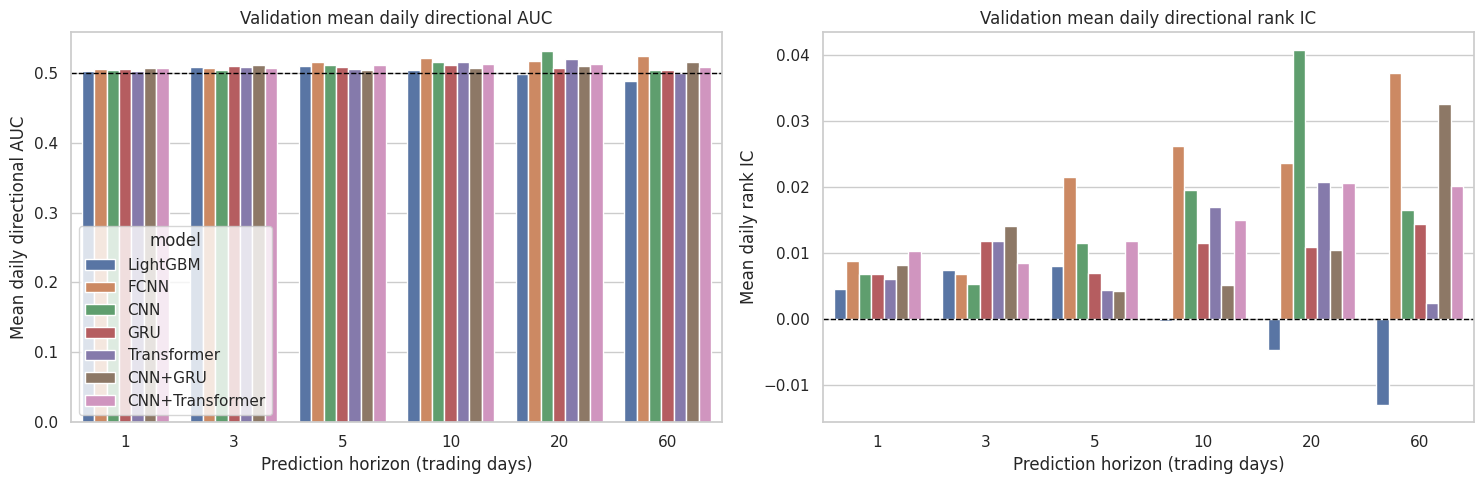

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=validation_model_metrics,
    x="window",
    y="mean_daily_directional_auc",
    hue="model",
    ax=axes[0],
)
axes[0].axhline(0.5, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Validation mean daily directional AUC")
axes[0].set_xlabel("Prediction horizon (trading days)")
axes[0].set_ylabel("Mean daily directional AUC")

sns.barplot(
    data=validation_model_metrics,
    x="window",
    y="mean_daily_rank_ic",
    hue="model",
    ax=axes[1],
)
axes[1].axhline(0.0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Validation mean daily directional rank IC")
axes[1].set_xlabel("Prediction horizon (trading days)")
axes[1].set_ylabel("Mean daily rank IC")
axes[1].legend_.remove()
plt.tight_layout()
plt.show()


## 11. Refit selected systems on train + validation and predict test


In [30]:
def train_neural_fixed_epochs(model_name, window, epochs, fit_rows):
    model_number = list(MODEL_CLASSES).index(model_name)
    seed_everything(RANDOM_STATE + 10_000 + 100 * window + model_number)
    target_col = f"target_class_{window}d"
    loader = make_loader(fit_rows, window, shuffle=True)
    class_weights = torch.as_tensor(
        balanced_class_weights(fit_rows[target_col].astype(int)),
        dtype=torch.float32,
        device=DEVICE,
    )
    model = MODEL_CLASSES[model_name]().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for sequences, ticker_ids, targets, _ in loader:
            sequences = sequences.to(DEVICE)
            ticker_ids = ticker_ids.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(sequences, ticker_ids)
            loss, _, _ = combined_classification_loss(logits, targets, class_weights)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        print(f"Final {window}d {model_name} epoch={epoch:02d} loss={np.mean(losses):.4f}")
    return model


selected_test_frames = []
saved_model_paths = {}

for selection in best_model_by_window.itertuples(index=False):
    window = int(selection.window)
    model_name = selection.model
    target_col = f"target_class_{window}d"
    safe_name = model_name.replace("+", "_plus_").lower()
    test_part_path = CHECKPOINT_DIR / f"test_selected_{window}d.parquet"
    final_model_path = MODEL_RUN_DIR / (
        f"final_{safe_name}_{window}d.joblib" if model_name == "LightGBM"
        else f"final_{safe_name}_{window}d.pt"
    )

    if RESUME_COMPLETED_WINDOWS and test_part_path.exists() and final_model_path.exists():
        print(f"Loading completed refit/test window: {window}d")
        selected_test_frames.append(pd.read_parquet(test_part_path))
        saved_model_paths[window] = str(final_model_path)
        continue

    fit_rows = get_model_rows(window, "train_validation")
    test_rows = get_model_rows(window, "test_prediction")

    if model_name == "LightGBM":
        tree_count = int(selection.best_iteration)
        fit_targets = fit_rows[target_col].astype(int).to_numpy()
        class_weights = balanced_class_weights(fit_targets)
        final_model = make_lgbm(tree_count, RANDOM_STATE + 10_000 + window)
        final_model.fit(
            fit_rows[lagged_feature_cols],
            fit_targets,
            sample_weight=class_weights[fit_targets],
        )
        probabilities = final_model.predict_proba(test_rows[lagged_feature_cols])
        positions = np.arange(len(test_rows))
        joblib.dump(final_model, final_model_path)
    else:
        epochs = int(selection.best_epoch)
        final_model = train_neural_fixed_epochs(model_name, window, epochs, fit_rows)
        positions, probabilities = neural_predict(
            final_model, make_loader(test_rows, window, shuffle=False)
        )
        torch.save({
            "run_fingerprint": RUN_FINGERPRINT,
            "window": window,
            "model_name": model_name,
            "best_epoch": epochs,
            "state_dict": {k: v.detach().cpu() for k, v in final_model.state_dict().items()},
            "feature_cols": feature_cols,
            "lookback": LOOKBACK,
            "ticker_to_id": ticker_to_id,
            "directional_loss_weight": DIRECTIONAL_LOSS_WEIGHT,
        }, final_model_path)

    frame = make_prediction_frame(
        test_rows, positions, probabilities, window, model_name
    )
    frame.to_parquet(test_part_path, index=False)
    selected_test_frames.append(frame)
    saved_model_paths[window] = str(final_model_path)
    del final_model, fit_rows, test_rows, probabilities
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Saved refit/test window:", window)


Final 1d CNN+GRU epoch=01 loss=1.7781
Final 1d CNN+GRU epoch=02 loss=1.7639
Final 1d CNN+GRU epoch=03 loss=1.7597
Final 1d CNN+GRU epoch=04 loss=1.7580
Final 1d CNN+GRU epoch=05 loss=1.7571
Final 1d CNN+GRU epoch=06 loss=1.7562
Saved refit/test window: 1
Final 3d CNN+GRU epoch=01 loss=1.7753
Final 3d CNN+GRU epoch=02 loss=1.7619
Final 3d CNN+GRU epoch=03 loss=1.7578
Final 3d CNN+GRU epoch=04 loss=1.7550
Final 3d CNN+GRU epoch=05 loss=1.7529
Final 3d CNN+GRU epoch=06 loss=1.7513
Final 3d CNN+GRU epoch=07 loss=1.7487
Final 3d CNN+GRU epoch=08 loss=1.7476
Saved refit/test window: 3
Final 5d FCNN epoch=01 loss=1.7726
Final 5d FCNN epoch=02 loss=1.7626
Final 5d FCNN epoch=03 loss=1.7571
Final 5d FCNN epoch=04 loss=1.7485
Final 5d FCNN epoch=05 loss=1.7410
Final 5d FCNN epoch=06 loss=1.7320
Final 5d FCNN epoch=07 loss=1.7232
Final 5d FCNN epoch=08 loss=1.7099
Saved refit/test window: 5
Final 10d FCNN epoch=01 loss=1.7711
Final 10d FCNN epoch=02 loss=1.7580
Final 10d FCNN epoch=03 loss=1.7426

## 12. Test diagnostics and consolidated outputs


In [31]:
def merge_window_predictions(frames):
    merged = None
    for frame in frames:
        window = int(frame["window"].iloc[0])
        current = frame.drop(columns=["window"]).rename(columns={
            "model": f"selected_model_{window}d",
            "actual_class": f"actual_class_{window}d",
            "actual_future_rank": f"actual_future_rank_{window}d",
        })
        merged = current if merged is None else merged.merge(
            current, on=["date", "ticker"], how="outer"
        )
    return merged.sort_values(["date", "ticker"]).reset_index(drop=True)


test_metric_rows = []
for frame in selected_test_frames:
    window = int(frame["window"].iloc[0])
    observed = frame["actual_class"].notna() & frame["actual_future_rank"].notna()
    probability_cols = [
        f"prob_bottom20_{window}d",
        f"prob_middle60_{window}d",
        f"prob_top20_{window}d",
    ]
    if observed.any():
        metrics = multiclass_metrics(
            frame.loc[observed, "actual_class"].astype(int),
            frame.loc[observed, probability_cols],
            frame.loc[observed, "date"],
            frame.loc[observed, "actual_future_rank"],
        )
        test_metric_rows.append({
            "window": window,
            "selected_model": frame["model"].iloc[0],
            **metrics,
        })

test_selected_metrics = pd.DataFrame(test_metric_rows)
validation_selected_predictions = merge_window_predictions(selected_validation_frames)
test_selected_predictions = merge_window_predictions(selected_test_frames)
display(test_selected_metrics)
display(test_selected_predictions.head())


,window,selected_model,n_observations,n_dates,n_directional_auc_dates,n_rank_ic_dates,accuracy,balanced_accuracy,macro_f1,mean_daily_directional_auc,mean_daily_rank_ic,mean_daily_macro_auc,mean_daily_extreme_auc,mean_daily_bottom_auc,mean_daily_middle_auc,mean_daily_top_auc,pooled_macro_auc,log_loss
0,1,CNN+GRU,250000,500,500,500,0.505704,0.412395,0.409985,0.507527,0.011036,0.631489,0.618288,0.619149,0.657892,0.617427,0.631450,1.044997
1,3,CNN+GRU,249000,498,498,498,0.481715,0.411152,0.404265,0.509028,0.011578,0.621255,0.602208,0.604960,0.659348,0.599457,0.621133,1.050824
2,5,FCNN,248000,496,496,496,0.450411,0.407299,0.394027,0.514393,0.020812,0.606145,0.581705,0.567070,0.655026,0.596340,0.605623,1.066591
3,10,FCNN,245500,491,491,491,0.418872,0.399118,0.377981,0.513657,0.014576,0.585899,0.554063,0.555327,0.649571,0.552798,0.585573,1.094095
4,20,CNN,240500,481,481,481,0.399289,0.393400,0.365577,0.514945,0.016674,0.578091,0.545134,0.555145,0.644004,0.535124,0.577259,1.136919
5,60,FCNN,220499,441,441,441,0.428319,0.408230,0.386455,0.520252,0.024272,0.590080,0.558325,0.559362,0.653590,0.557288,0.591205,1.100131


,date,ticker,actual_class_1d,actual_future_rank_1d,selected_model_1d,prob_bottom20_1d,prob_middle60_1d,prob_top20_1d,actual_class_3d,actual_future_rank_3d,selected_model_3d,prob_bottom20_3d,prob_middle60_3d,prob_top20_3d,actual_class_5d,actual_future_rank_5d,selected_model_5d,prob_bottom20_5d,prob_middle60_5d,prob_top20_5d,actual_class_10d,actual_future_rank_10d,selected_model_10d,prob_bottom20_10d,prob_middle60_10d,prob_top20_10d,actual_class_20d,actual_future_rank_20d,selected_model_20d,prob_bottom20_20d,prob_middle60_20d,prob_top20_20d,actual_class_60d,actual_future_rank_60d,selected_model_60d,prob_bottom20_60d,prob_middle60_60d,prob_top20_60d
0,2024-01-02,A,0,0.034,CNN+GRU,0.184254,0.603802,0.211944,0,0.046,CNN+GRU,0.201118,0.579900,0.218982,0,0.042,FCNN,0.193083,0.521500,0.285417,0,0.146,FCNN,0.136532,0.556699,0.306769,0,0.192,CNN,0.030751,0.443080,0.526170,1,0.394,FCNN,0.162304,0.410851,0.426845
1,2024-01-02,AA,0,0.036,CNN+GRU,0.464952,0.115284,0.419764,0,0.152,CNN+GRU,0.462649,0.159665,0.377686,0,0.110,FCNN,0.277484,0.159558,0.562958,0,0.014,FCNN,0.536520,0.185542,0.277938,0,0.080,CNN,0.140520,0.163674,0.695806,1,0.286,FCNN,0.832058,0.140058,0.027884
2,2024-01-02,AAL,0,0.126,CNN+GRU,0.420463,0.176313,0.403224,2,0.906,CNN+GRU,0.469795,0.191819,0.338386,2,0.976,FCNN,0.257758,0.174208,0.568034,1,0.372,FCNN,0.515402,0.157219,0.327379,2,0.806,CNN,0.120599,0.255664,0.623736,1,0.648,FCNN,0.447257,0.287226,0.265518
3,2024-01-02,AAP,1,0.480,CNN+GRU,0.460074,0.126457,0.413468,1,0.602,CNN+GRU,0.474892,0.194581,0.330527,1,0.414,FCNN,0.223153,0.194108,0.582739,1,0.580,FCNN,0.541136,0.185279,0.273585,2,0.908,CNN,0.120098,0.187249,0.692653,2,0.946,FCNN,0.820185,0.145129,0.034685
4,2024-01-02,AAPL,1,0.652,CNN+GRU,0.255678,0.441014,0.303308,1,0.308,CNN+GRU,0.224489,0.365066,0.410445,1,0.528,FCNN,0.212919,0.467562,0.319519,1,0.554,FCNN,0.258121,0.394454,0.347425,1,0.484,CNN,0.120728,0.513753,0.365519,0,0.100,FCNN,0.042430,0.307700,0.649870


In [32]:
validation_metrics_path = RESULTS_DIR / f"02_validation_model_metrics{OUTPUT_SUFFIX}.csv"
best_models_path = RESULTS_DIR / f"02_best_model_by_window{OUTPUT_SUFFIX}.csv"
history_path = RESULTS_DIR / f"02_neural_training_history{OUTPUT_SUFFIX}.csv"
test_metrics_path = RESULTS_DIR / f"02_test_selected_metrics{OUTPUT_SUFFIX}.csv"
validation_predictions_path = PREDICTIONS_DIR / (
    f"02_validation_selected_probabilities{OUTPUT_SUFFIX}.parquet"
)
test_predictions_path = PREDICTIONS_DIR / (
    f"02_test_selected_probabilities{OUTPUT_SUFFIX}.parquet"
)
preprocessing_path = MODEL_RUN_DIR / f"preprocessing{OUTPUT_SUFFIX}.joblib"
metadata_path = RESULTS_DIR / f"02_multiclass_metadata{OUTPUT_SUFFIX}.json"

validation_model_metrics.to_csv(validation_metrics_path, index=False)
best_model_by_window.to_csv(best_models_path, index=False)
training_history.to_csv(history_path, index=False)
test_selected_metrics.to_csv(test_metrics_path, index=False)
validation_selected_predictions.to_parquet(validation_predictions_path, index=False)
test_selected_predictions.to_parquet(test_predictions_path, index=False)

joblib.dump({
    "run_fingerprint": RUN_FINGERPRINT,
    "feature_cols": feature_cols,
    "rank_feature_cols": rank_feature_cols,
    "continuous_feature_cols": continuous_feature_cols,
    "continuous_center": continuous_center,
    "continuous_scale": continuous_scale,
    "feature_fill_values": feature_fill_values,
    "lagged_feature_cols": lagged_feature_cols,
    "ticker_to_id": ticker_to_id,
    "lookback": LOOKBACK,
    "directional_loss_weight": DIRECTIONAL_LOSS_WEIGHT,
    "class_weighting": "balanced inverse frequency",
}, preprocessing_path)

metadata = {
    **run_settings,
    "run_fingerprint": RUN_FINGERPRINT,
    "classes": {"0": "bottom20", "1": "middle60", "2": "top20"},
    "feature_timing": "prediction date t uses histories ending at t-1",
    "nn_sample": "one complete date: stocks x lookback x features",
    "cross_stock_context": "ticker embedding plus cross-sectional self-attention",
    "selection_rule": (
        "highest mean_daily_directional_auc; highest mean_daily_rank_ic tie-break; "
        "highest mean_daily_extreme_auc second tie-break; lowest log_loss final tie-break"
    ),
    "direction_score": "prob_top20 - prob_bottom20",
    "saved_model_paths": {str(k): v for k, v in saved_model_paths.items()},
}
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
for path in [
    validation_metrics_path,
    best_models_path,
    history_path,
    test_metrics_path,
    validation_predictions_path,
    test_predictions_path,
    preprocessing_path,
    metadata_path,
    *[Path(path) for path in saved_model_paths.values()],
]:
    print(" -", path)


Saved:
 - /content/drive/MyDrive/alpha_ml/results/02_validation_model_metrics_directional.csv
 - /content/drive/MyDrive/alpha_ml/results/02_best_model_by_window_directional.csv
 - /content/drive/MyDrive/alpha_ml/results/02_neural_training_history_directional.csv
 - /content/drive/MyDrive/alpha_ml/results/02_test_selected_metrics_directional.csv
 - /content/drive/MyDrive/alpha_ml/results/predictions/02_validation_selected_probabilities_directional.parquet
 - /content/drive/MyDrive/alpha_ml/results/predictions/02_test_selected_probabilities_directional.parquet
 - /content/drive/MyDrive/alpha_ml/models/02_cross_sectional/a2f95b346ee9/preprocessing_directional.joblib
 - /content/drive/MyDrive/alpha_ml/results/02_multiclass_metadata_directional.json
 - /content/drive/MyDrive/alpha_ml/models/02_cross_sectional/a2f95b346ee9/final_cnn_plus_gru_1d.pt
 - /content/drive/MyDrive/alpha_ml/models/02_cross_sectional/a2f95b346ee9/final_cnn_plus_gru_3d.pt
 - /content/drive/MyDrive/alpha_ml/models/02_cr

## Reading the results

- `mean_daily_directional_auc` is the primary validation selection metric. Among stocks that actually finish in the bottom or top 20%, it tests whether `P(top20) - P(bottom20)` ranks future top stocks above future bottom stocks.
- `mean_daily_rank_ic` is the mean daily Spearman correlation between the same directional score and the full future cross-sectional return rank. It is the first tie-breaker.
- `mean_daily_extreme_auc` remains a diagnostic and the second tie-breaker; `log_loss` is the final tie-breaker.
- The neural loss combines balanced three-class cross-entropy with a direct bottom-versus-top cross-entropy term. LightGBM uses balanced row weights while retaining its multiclass objective.
- A completed horizon is stored under `results/02_checkpoints/<run fingerprint>/`; rerunning with identical settings skips it.
- The `_directional` suffix keeps all formal outputs separate from the previous 02 run.
- Test metrics are diagnostic only. Portfolio rules and horizon allocations must not be changed after inspecting test.
